In [5]:
import pandas as pd

data_path = "./data/cleaned-and-tidy-data.csv"

df = pd.read_csv(data_path)
df

,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37
...,...,...,...,...,...,...
1731,house,Jalisco,20.532264,-103.484418,175.0,121178.91
1732,house,Morelos,18.928986,-99.180215,100.0,47417.83
1733,house,Yucatán,21.028404,-89.653006,81.0,39524.23
1734,house,San Luis Potosí,22.118304,-101.032194,360.0,245050.24


### The explicit interface — a complete reference:

✅ Always use the explicit (object-oriented) interface in this course and in professional work.

The implicit interface looks shorter for simple cases, but breaks down as soon as you add a second plot, pass axes to Seaborn, or write reusable code. The explicit interface has no such limitations.

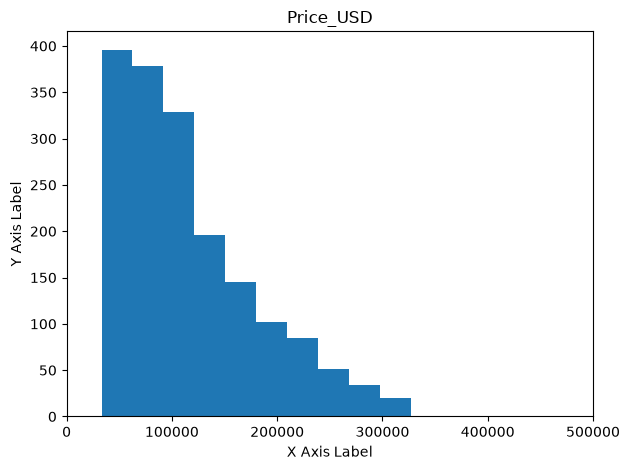

In [2]:
import matplotlib.pyplot as plt

# Step 1: Create the canvas and the plot area
fig, ax = plt.subplots()

# Step 2: Draw on the specific axes object
ax.hist(df["price_usd"])


# Step 3: Label and customize using ax.set_* methods
ax.set_title("Price_USD")
ax.set_xlabel("X Axis Label")
ax.set_ylabel("Y Axis Label")
ax.set_xlim(0, 500000)         # Optional: fix axis range

# Step 4: Display
plt.tight_layout()  # Prevent labels from being cut off
plt.show()          # Render the figure


Text(0.5, 1.0, 'Distribution of Property Size')

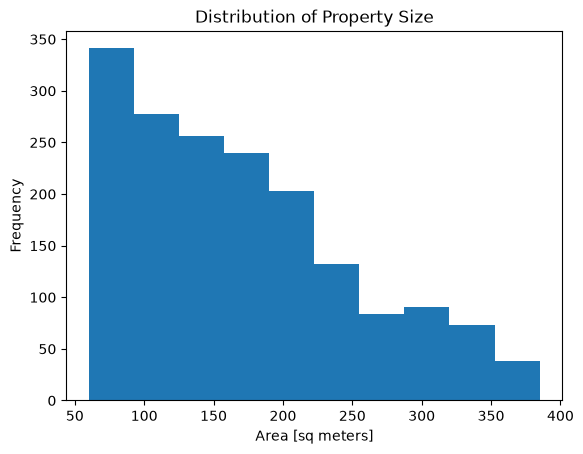

In [3]:
# Create histogram for area_m2
fig, ax = plt.subplots()

ax.hist(df["area_m2"])

# Add x-axis label, y-axis label & title
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Property Size")


In [4]:
# 1. Get the unique category names on the column "property_type"
prop_types = df["property_type"].unique()
print(prop_types)

<StringArray>
['house', 'apartment']
Length: 2, dtype: str


### Bivariate Analysis : Categorical vs. Numerical

#### How to read a boxplot:

- Box width (IQR): A wide box means high variability in the middle 50%. A narrow box means tight clustering.
- Median line position: Is the median close to the center of the box, or pushed toward one edge? A median pushed to the left (closer to Q1) indicates right skew within the middle 50%.
- Whisker lengths: Unequal whiskers confirm asymmetry. A long right whisker means the upper half of the non-outlier data is more spread out.
- Outlier dots: A long string of dots on one side signals a heavy tail. For housing prices, we almost always see dots on the right (expensive properties).

/tmp/ipykernel_21790/2224250552.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data_by_type, tick_labels=prop_types, vert= False)


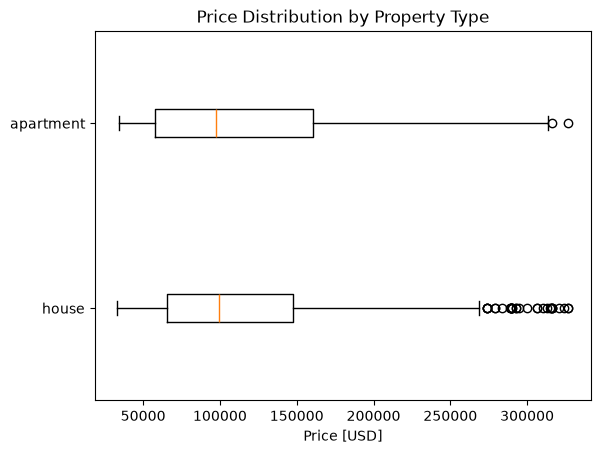

In [6]:
# Comparing Property types

data_by_type = [df[df["property_type"] == label] ["price_usd"] for label in prop_types]

fig, ax = plt.subplots()

#box plot
ax.boxplot(data_by_type, tick_labels=prop_types, vert= False)

ax.set_title("Price Distribution by Property Type")
ax.set_xlabel("Price [USD]")

plt.show()

/tmp/ipykernel_21790/3806435252.py:17: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data_by_state, tick_labels=selected_states, vert=False)


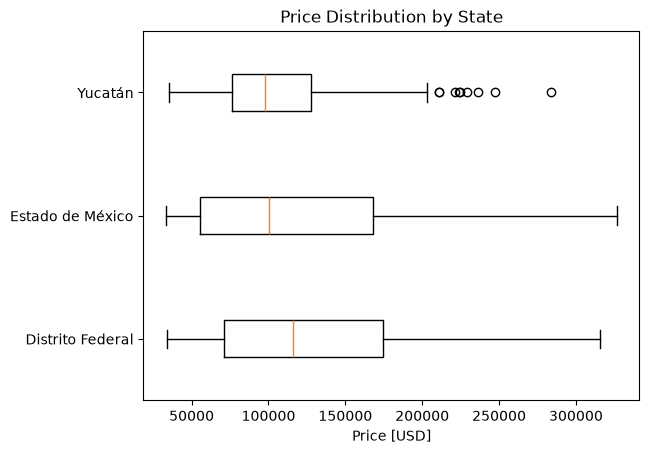

In [7]:
# Comparing States

# 1. Define your selected states
selected_states = (
    df["state"]
    .value_counts()
    .head(3)
    .index.tolist()
)
# 2. Prepare the data
data_by_state = [df[df["state"] == state]["price_usd"] for state in selected_states]

# 3. Plot
fig, ax = plt.subplots()

# FIX: Use 'tick_labels' instead of 'labels'
ax.boxplot(data_by_state, tick_labels=selected_states, vert=False)

ax.set_title("Price Distribution by State")
ax.set_xlabel("Price [USD]")
plt.show()

In [8]:
df["price_usd"] < df["price_usd"].quantile(0.90)

0        True
1        True
2        True
3        True
4        True
        ...  
1731     True
1732     True
1733     True
1734    False
1735     True
Name: price_usd, Length: 1736, dtype: bool

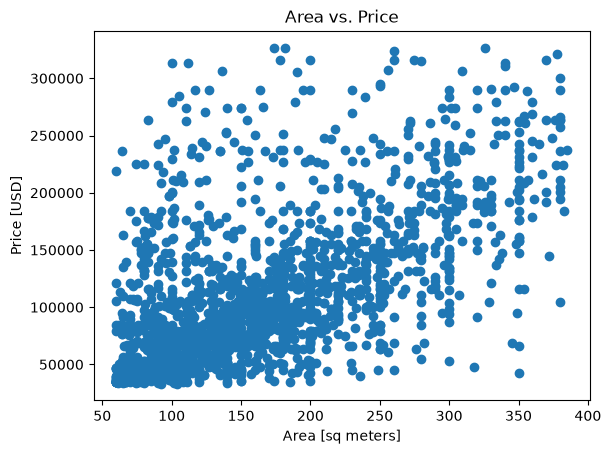

In [9]:
# 1. Create the Figure and Axes objects
fig, ax = plt.subplots()

# 2. Plot on the specific axes object
ax.scatter(x=df["area_m2"], y=df["price_usd"])

# 3. Set labels and title (Note the "set_" prefix)
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Area vs. Price")

plt.show()

Original: 1736 rows
Cleaned: 1365 rows
Removed: 371 rows


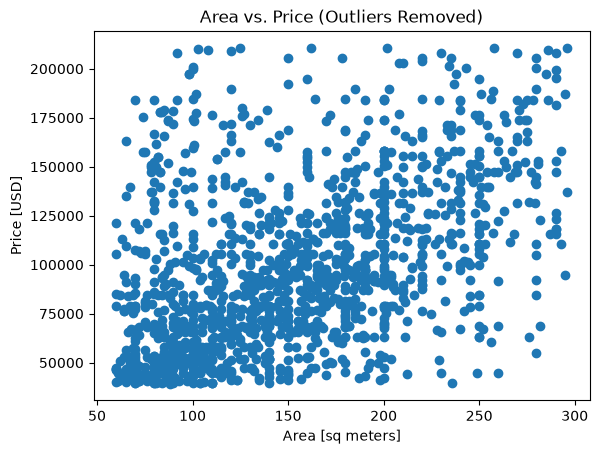

In [10]:
# Define cutoff percentages
lower_cut = 0.05  # Remove bottom 5%
upper_cut = 0.90  # Keep up to 90th percentile

# Filter the data
df_clean = (
    df[
        (df["price_usd"] > df["price_usd"].quantile(lower_cut)) &
        (df["price_usd"] < df["price_usd"].quantile(upper_cut)) &
        (df["area_m2"] < df["area_m2"].quantile(upper_cut)) # <-- Large area outliers also skew the scatter plot
    ]
)

# Show what changed
print(f"Original: {len(df)} rows")
print(f"Cleaned: {len(df_clean)} rows")
print(f"Removed: {len(df) - len(df_clean)} rows")

# Plot
fig, ax = plt.subplots()
ax.scatter(df_clean["area_m2"], df_clean["price_usd"])
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Area vs. Price (Outliers Removed)")
plt.show()

In [13]:
import seaborn as sns

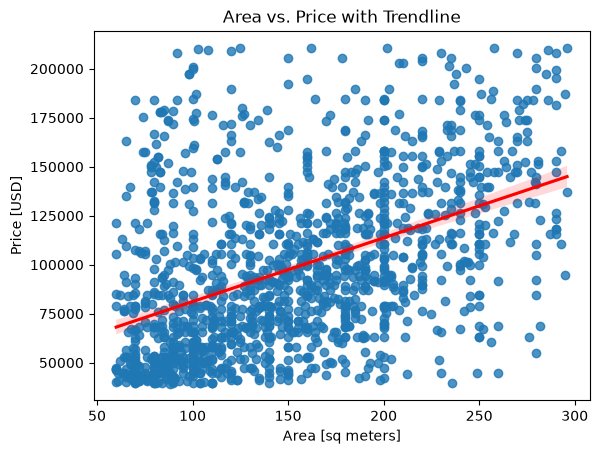

In [14]:
# Create figure and axis explicitly
fig, ax = plt.subplots()

# Use Seaborn to plot scatter + trendline
sns.regplot(
    data=df_clean, 
    x="area_m2", 
    y="price_usd", 
    line_kws={"color": "red"},  # Make the line distinct
    ax=ax  # Pass the axis to seaborn
)

ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Area vs. Price with Trendline")
plt.show()

In [17]:
# Split by 'state', select the 'price_usd' column, and apply the mean() function
avg_price_by_state = df.groupby('state')['price_usd'].mean().sort_values(ascending=False)

print(avg_price_by_state)

state
Querétaro                          133955.913417
Guanajuato                         133277.965833
Nuevo León                         129221.985834
Distrito Federal                   128347.267365
Quintana Roo                       128065.415734
Chihuahua                          127073.851184
Jalisco                            123386.472237
Estado de México                   122723.490600
Campeche                           121734.633333
Puebla                             121732.974294
Guerrero                           119854.276015
Sonora                             114547.881798
Morelos                            112697.295615
Aguascalientes                     110543.888316
Baja California Sur                109069.339158
Yucatán                            108580.388526
Chiapas                            104342.313388
Veracruz de Ignacio de la Llave     96928.125254
Hidalgo                             94012.326563
Sinaloa                             93922.152490
Tamaulipas    

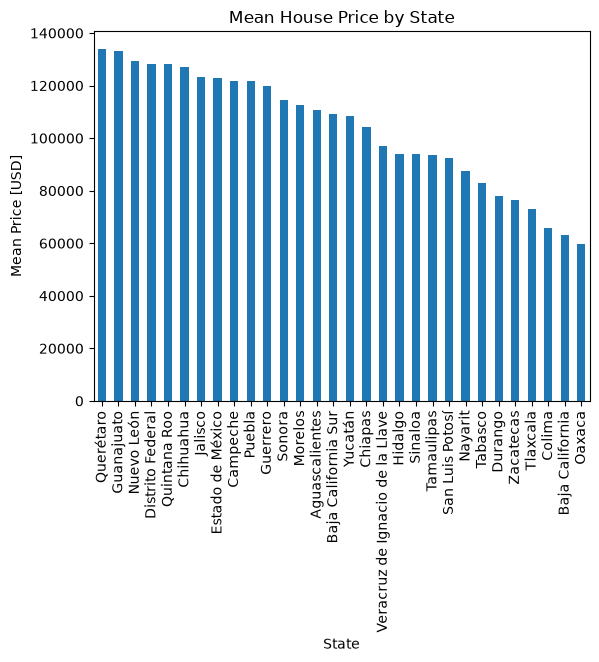

In [18]:
fig, ax = plt.subplots()

avg_price_by_state.plot(
    kind="bar",
    ax=ax
)

ax.set_xlabel("State")
ax.set_ylabel("Mean Price [USD]")
ax.set_title("Mean House Price by State")

plt.show()


In [19]:
toy = pd.DataFrame({
    "state":     ["DF", "DF", "DF", "YUC", "YUC", "MEX"],
    "price_usd": [120000, 90000, 150000, 70000, 80000, 100000]
})
toy

,state,price_usd
0,DF,120000
1,DF,90000
2,DF,150000
3,YUC,70000
4,YUC,80000
5,MEX,100000


In [22]:
print(toy.groupby('state').mean())

       price_usd
state           
DF      120000.0
MEX     100000.0
YUC      75000.0
